Just getting started on some analysis testing! - Aidan

In [2]:
import pandas as pd

In [10]:
df = pd.read_csv("data/RelevantData.csv")
df.head()

,ResponseId,PID,HS_1,HS_2,HS_3,FM_1,FM_2,GM_1,GM_2,Dif_import1,Dif_import2,Dif_impos1,Dif_impos2,CurrentCountry_Cleaned,K12Country_Cleaned,Age,Sex,Ethnicity,Language
0,R_x3h5VdR8R7BaQud,63ffc4d9948fc9133fd57b0f,6,1,1,1,3,3,4,4,3,1,3,Germany,Albania,25,Female,White,Albanian
1,R_2YM6WVIQojrB0Uc,5fa073d2088cae0c001cb4a8,5,5,5,3,3,4,4,3,4,1,1,Germany,Australia,33,Female,White,English
2,R_2cvktNtKzsC9rRG,640873babaeb4cd5458da266,5,3,5,1,1,6,6,1,3,1,6,Germany,Bangladesh,28,Female,Asian,Bengali
3,R_1ghXjNUaiAHNqSA,63bded22115f099517d31c54,4,4,4,4,4,4,4,4,4,4,4,Germany,Bangladesh,25,Male,Asian,Bengali
4,R_2w1tGapiFQr2voI,64312aea1c7feb3eadf021a1,6,1,3,1,1,6,6,6,4,1,1,Germany,Brazil,27,Male,White,Portuguese


In [11]:
df["country"] = df["CurrentCountry_Cleaned"]
df["country"].value_counts()

country
USA             156
South Africa    152
Spain           152
UK              152
Germany         150
Mexico          147
Scandinavia      94
France            1
Name: count, dtype: int64

Creating group columns 

Flipping HS_1 as the question is flipped

In [12]:
df["help_seeking"] = df[["HS_1", "HS_2", "HS_3"]].mean(axis=1)
df["fixed_mindset"] = df[["FM_1", "FM_2"]].mean(axis=1)
df["growth_mindset"] = df[["GM_1", "GM_2"]].mean(axis=1)

df["difficulty_important"] = df[["Dif_import1", "Dif_import2"]].mean(axis=1)
df["difficulty_impossible"] = df[["Dif_impos1", "Dif_impos2"]].mean(axis=1)

Means by country

In [13]:
df.groupby("country")[[
    "growth_mindset",
    "fixed_mindset",
    "difficulty_important",
    "difficulty_impossible",
    "help_seeking"
]].mean()

,growth_mindset,fixed_mindset,difficulty_important,difficulty_impossible,help_seeking
country,,,,,
France,3.000000,4.500000,3.500000,4.000000,2.666667
Germany,3.820000,2.980000,3.626667,2.526667,3.866667
Mexico,4.649660,2.585034,3.897959,2.625850,4.253968
Scandinavia,4.005319,2.617021,3.351064,2.452128,3.719858
South Africa,4.835526,2.651316,4.203947,2.276316,4.381579
Spain,4.019737,2.858553,3.526316,2.634868,4.048246
UK,4.082237,2.736842,3.845395,2.424342,3.936404
USA,4.339744,2.605769,3.907051,2.394231,4.021368


some basic box plots

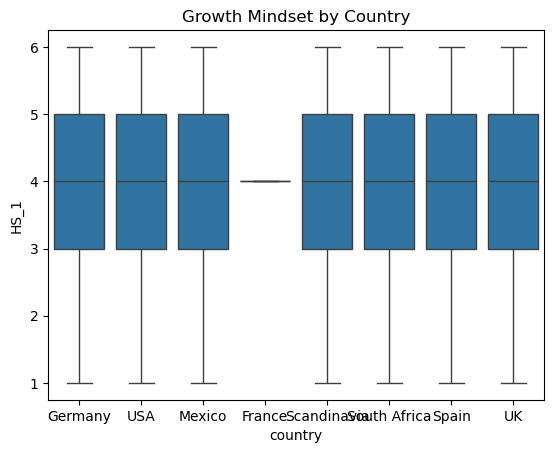

In [14]:
plt.figure()
sns.boxplot(data=df, x="country", y="HS_1")
plt.title("Growth Mindset by Country")
plt.show()

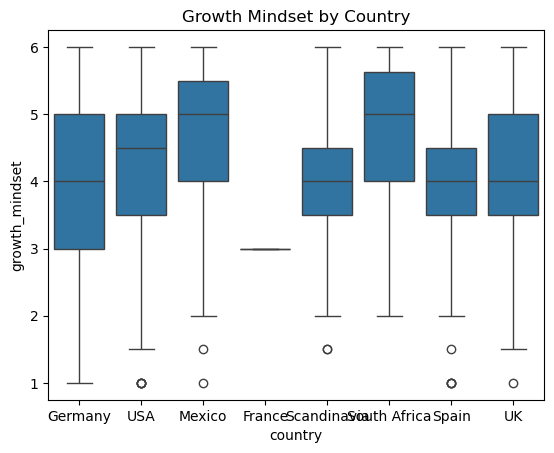

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(data=df, x="country", y="growth_mindset")
plt.title("Growth Mindset by Country")
plt.show()

bit of an issue with the names here...

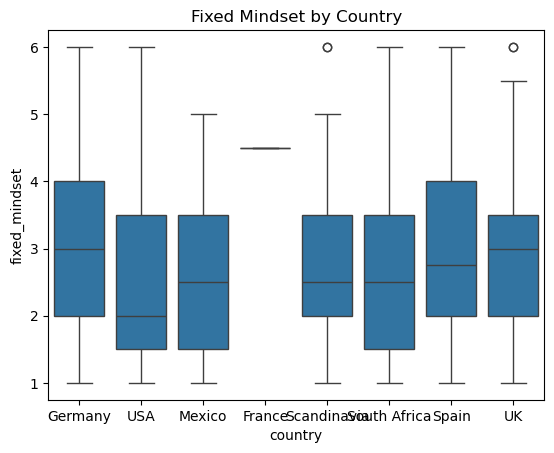

In [16]:
plt.figure()
sns.boxplot(data=df, x="country", y="fixed_mindset")
plt.title("Fixed Mindset by Country")
plt.show()

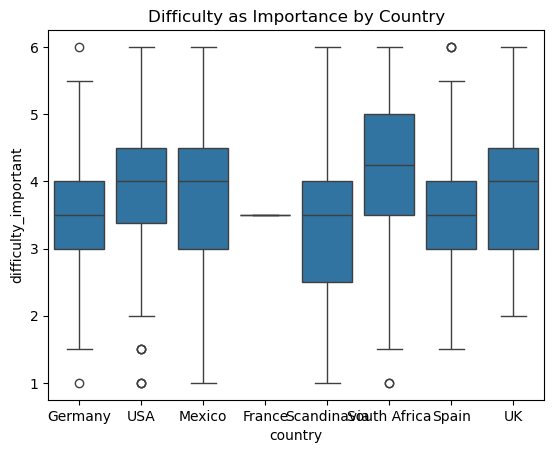

In [17]:
plt.figure()
sns.boxplot(data=df, x="country", y="difficulty_important")
plt.title("Difficulty as Importance by Country")
plt.show()

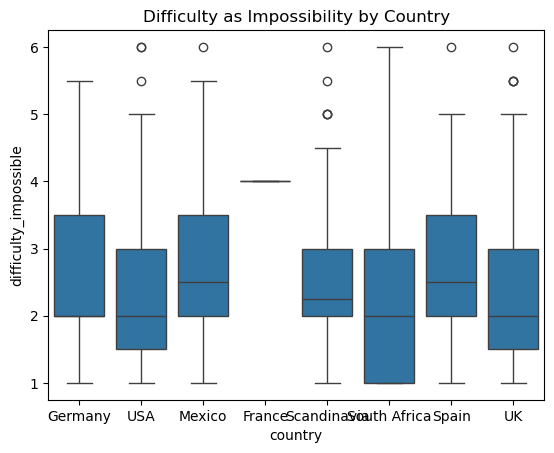

In [18]:
plt.figure()
sns.boxplot(data=df, x="country", y="difficulty_impossible")
plt.title("Difficulty as Impossibility by Country")
plt.show()

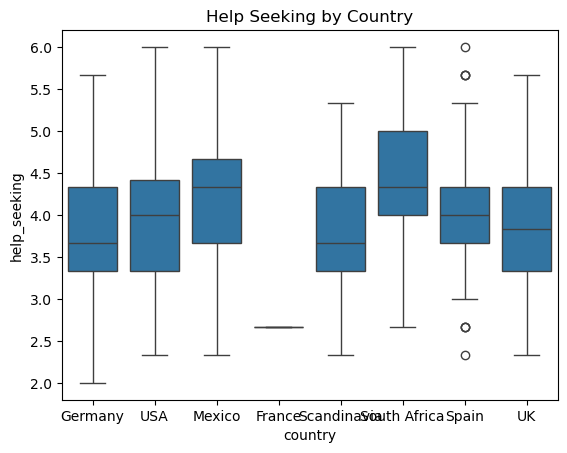

In [19]:
plt.figure()
sns.boxplot(data=df, x="country", y="help_seeking")
plt.title("Help Seeking by Country")
plt.show()

We probably need to do something to handle outliers here, perhaps? 

Also figuring out a cleaner way to present all of this: 

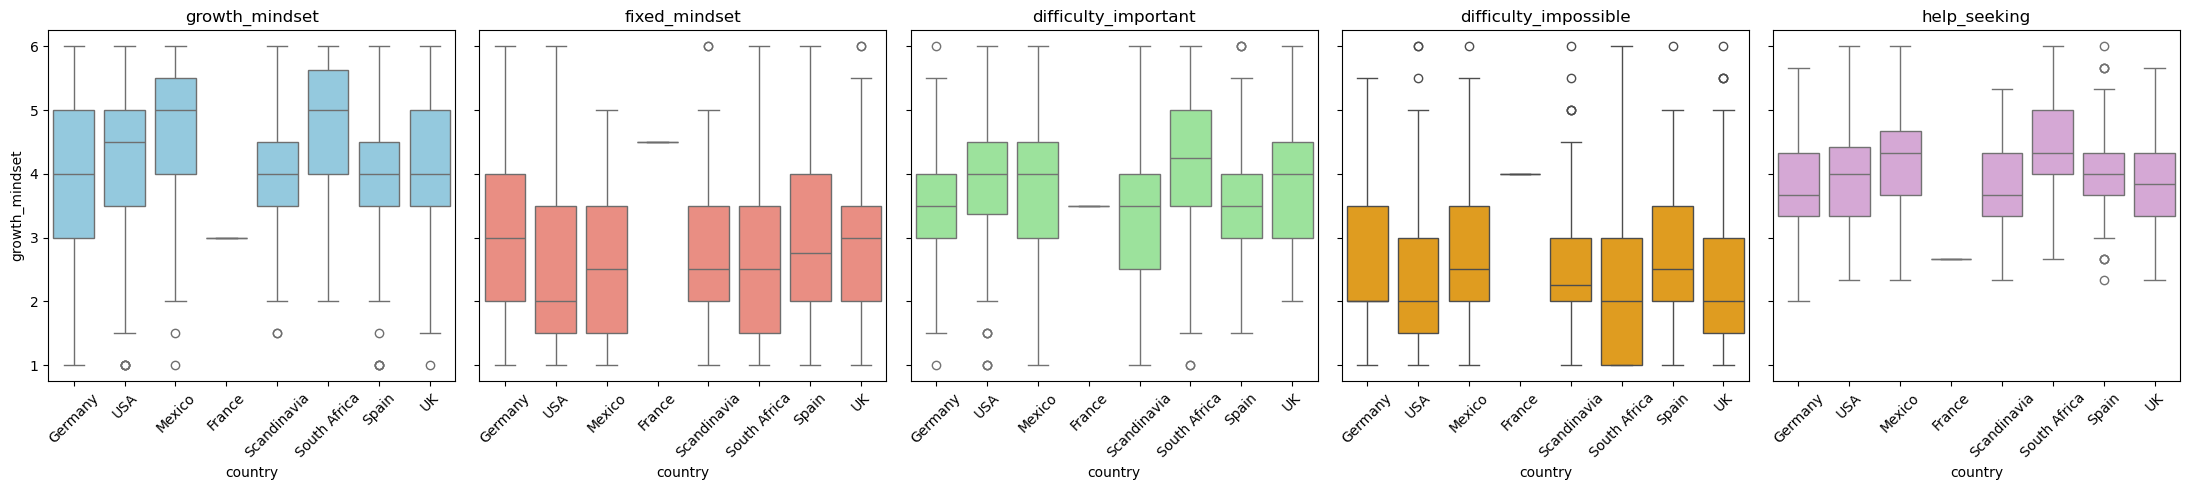

In [20]:
variables = [
    "growth_mindset",
    "fixed_mindset",
    "difficulty_important",
    "difficulty_impossible",
    "help_seeking"
]

colors = ["skyblue", "salmon", "lightgreen", "orange", "plum"]

fig, axes = plt.subplots(1, len(variables), figsize=(22, 5), sharey=True)

for i, var in enumerate(variables):
    sns.boxplot(
        data=df,
        x="country",
        y=var,
        ax=axes[i],
        color=colors[i]
    )
    axes[i].set_title(var)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Now moving on to some basic anova analysis

In [21]:
import scipy.stats as stats

variables = [
    "growth_mindset",
    "fixed_mindset",
    "difficulty_important",
    "difficulty_impossible",
    "help_seeking"
]

for var in variables:
    groups = [group[var].dropna() for name, group in df.groupby("country")]
    
    f_stat, p_val = stats.f_oneway(*groups)
    
    print(f"\n{var}")
    print(f"F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_val:.6f}")


growth_mindset
F-statistic: 13.6284
p-value: 0.000000

fixed_mindset
F-statistic: 1.9677
p-value: 0.056511

difficulty_important
F-statistic: 8.1244
p-value: 0.000000

difficulty_impossible
F-statistic: 1.9745
p-value: 0.055598

help_seeking
F-statistic: 11.2411
p-value: 0.000000


Going to add some analysis testing hypothesis: What determines perceived difficulty in education across countries?


In [22]:
df["difficulty_index"] = df[["difficulty_important", "difficulty_impossible"]].mean(axis=1)

In [24]:
import statsmodels.api as sm

X = df[["growth_mindset", "fixed_mindset", "help_seeking"]]
X = sm.add_constant(X)

y = df["difficulty_index"]

model = sm.OLS(y, X).fit(cov_type='HC3')  
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       difficulty_index   R-squared:                       0.178
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     53.82
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           2.97e-32
Time:                        11:21:05   Log-Likelihood:                -1084.9
No. Observations:                1005   AIC:                             2178.
Df Residuals:                    1001   BIC:                             2197.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.8118      0.196      4.

In [31]:
country_cols = [col for col in df.columns if col.startswith("country_")]

In [32]:
import statsmodels.api as sm

# Select regressors
country_cols = [col for col in df.columns if col.startswith("country_")]

X = df[
    ["growth_mindset", "fixed_mindset", "help_seeking"] + country_cols
]

X = sm.add_constant(X)
y = df["difficulty_index"]

model = sm.OLS(y, X).fit(cov_type='HC3')

print(model.summary())

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [27]:
print(df.columns)

Index(['ResponseId', 'PID', 'HS_1', 'HS_2', 'HS_3', 'FM_1', 'FM_2', 'GM_1',
       'GM_2', 'Dif_import1', 'Dif_import2', 'Dif_impos1', 'Dif_impos2',
       'CurrentCountry_Cleaned', 'K12Country_Cleaned', 'Age', 'Sex',
       'Ethnicity', 'Language', 'help_seeking', 'fixed_mindset',
       'growth_mindset', 'difficulty_important', 'difficulty_impossible',
       'difficulty_index', 'country_Germany', 'country_Mexico',
       'country_Scandinavia', 'country_South Africa', 'country_Spain',
       'country_UK', 'country_USA'],
      dtype='object')


In [28]:
df["country"] = df["CurrentCountry_Cleaned"]

In [33]:
print(X.dtypes)
print(y.dtype)

const                   float64
growth_mindset          float64
fixed_mindset           float64
help_seeking            float64
country_Germany            bool
country_Germany            bool
country_Mexico             bool
country_Mexico             bool
country_Scandinavia        bool
country_Scandinavia        bool
country_South Africa       bool
country_South Africa       bool
country_Spain              bool
country_Spain              bool
country_UK                 bool
country_UK                 bool
country_USA                bool
country_USA                bool
country_Germany            bool
country_Germany            bool
country_Mexico             bool
country_Mexico             bool
country_Scandinavia        bool
country_Scandinavia        bool
country_South Africa       bool
country_South Africa       bool
country_Spain              bool
country_Spain              bool
country_UK                 bool
country_UK                 bool
country_USA                bool
country_

In [36]:
import pandas as pd
import statsmodels.api as sm


df = df.loc[:, ~df.columns.duplicated()].copy()


country_cols = [col for col in df.columns if col.startswith("country_")]


reg_vars = ["difficulty_index", "growth_mindset", "fixed_mindset", "help_seeking"] + country_cols
reg_df = df[reg_vars].copy()


for col in country_cols:
    reg_df[col] = reg_df[col].astype(int)


for col in ["difficulty_index", "growth_mindset", "fixed_mindset", "help_seeking"]:
    reg_df[col] = pd.to_numeric(reg_df[col], errors="coerce")


reg_df = reg_df.dropna()


X = reg_df[["growth_mindset", "fixed_mindset", "help_seeking"] + country_cols]
X = sm.add_constant(X)
y = reg_df["difficulty_index"]


model = sm.OLS(y, X).fit(cov_type="HC3")
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       difficulty_index   R-squared:                       0.182
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     17.02
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           9.51e-29
Time:                        11:29:25   Log-Likelihood:                -1082.3
No. Observations:                1005   AIC:                             2187.
Df Residuals:                     994   BIC:                             2241.
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.6880 

/var/folders/dz/ll9mv3055qv5h4c7lg8f3b8h0000gn/T/ipykernel_1768/1499050440.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


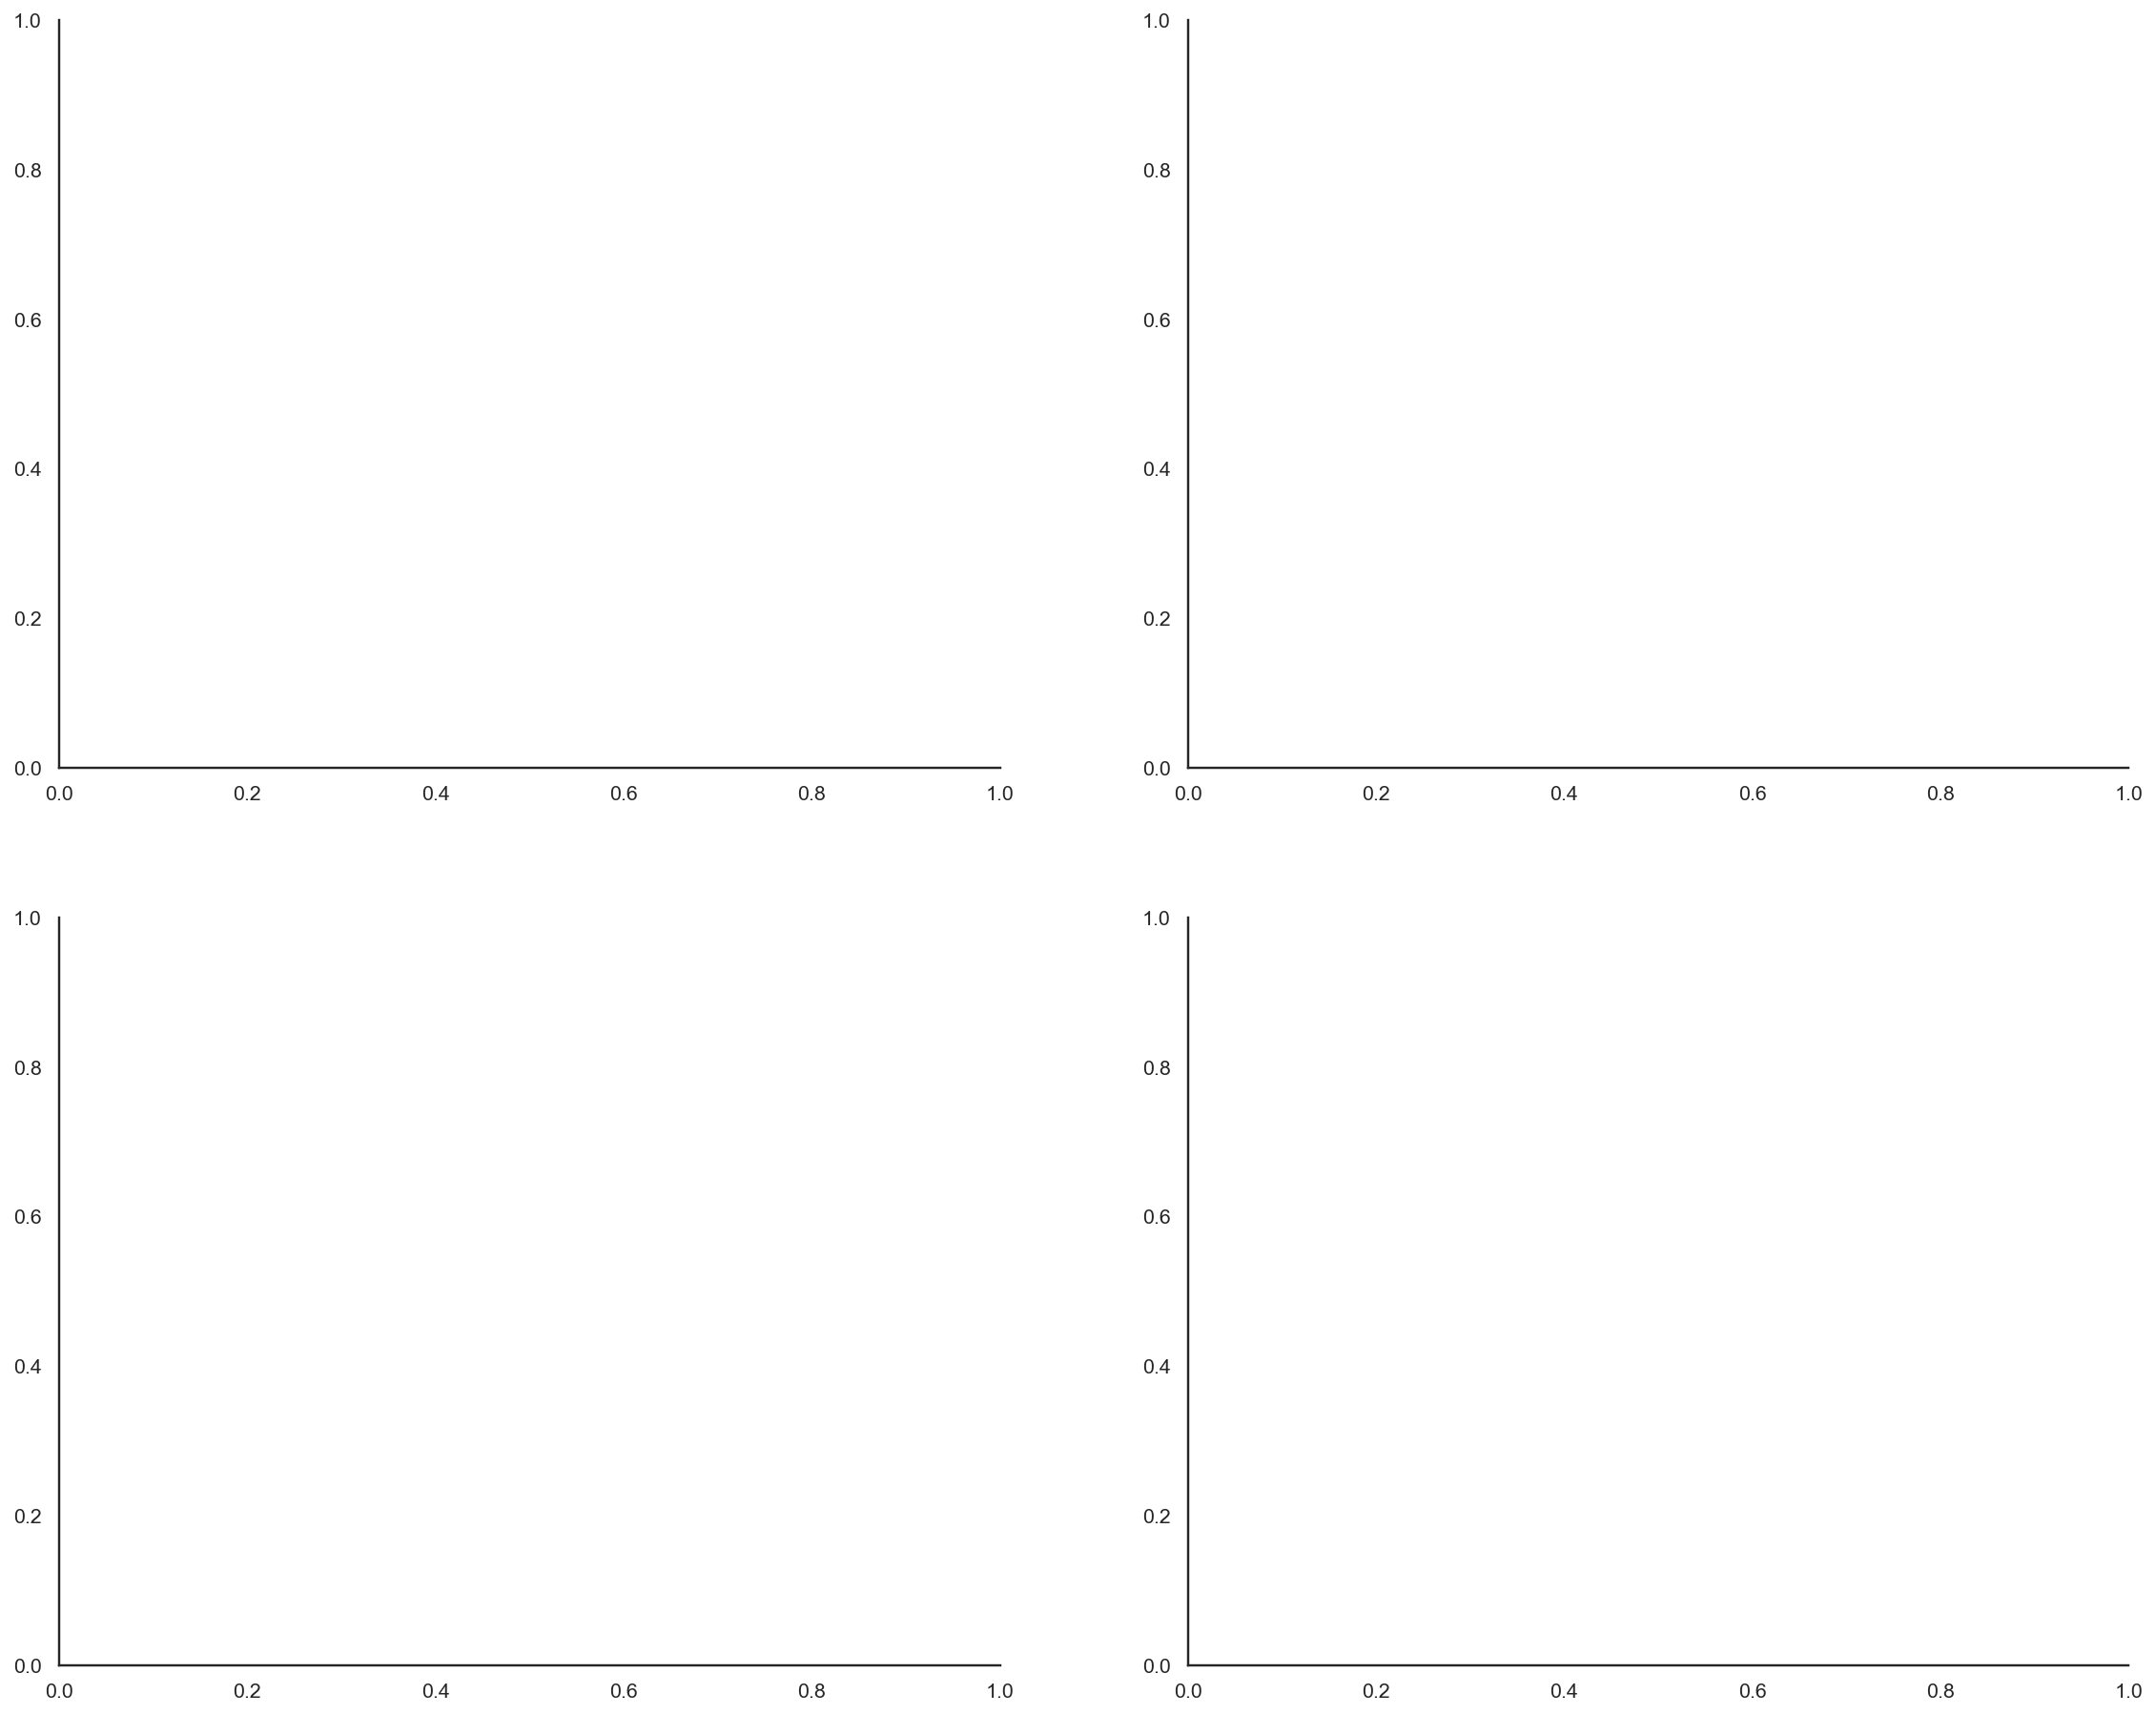

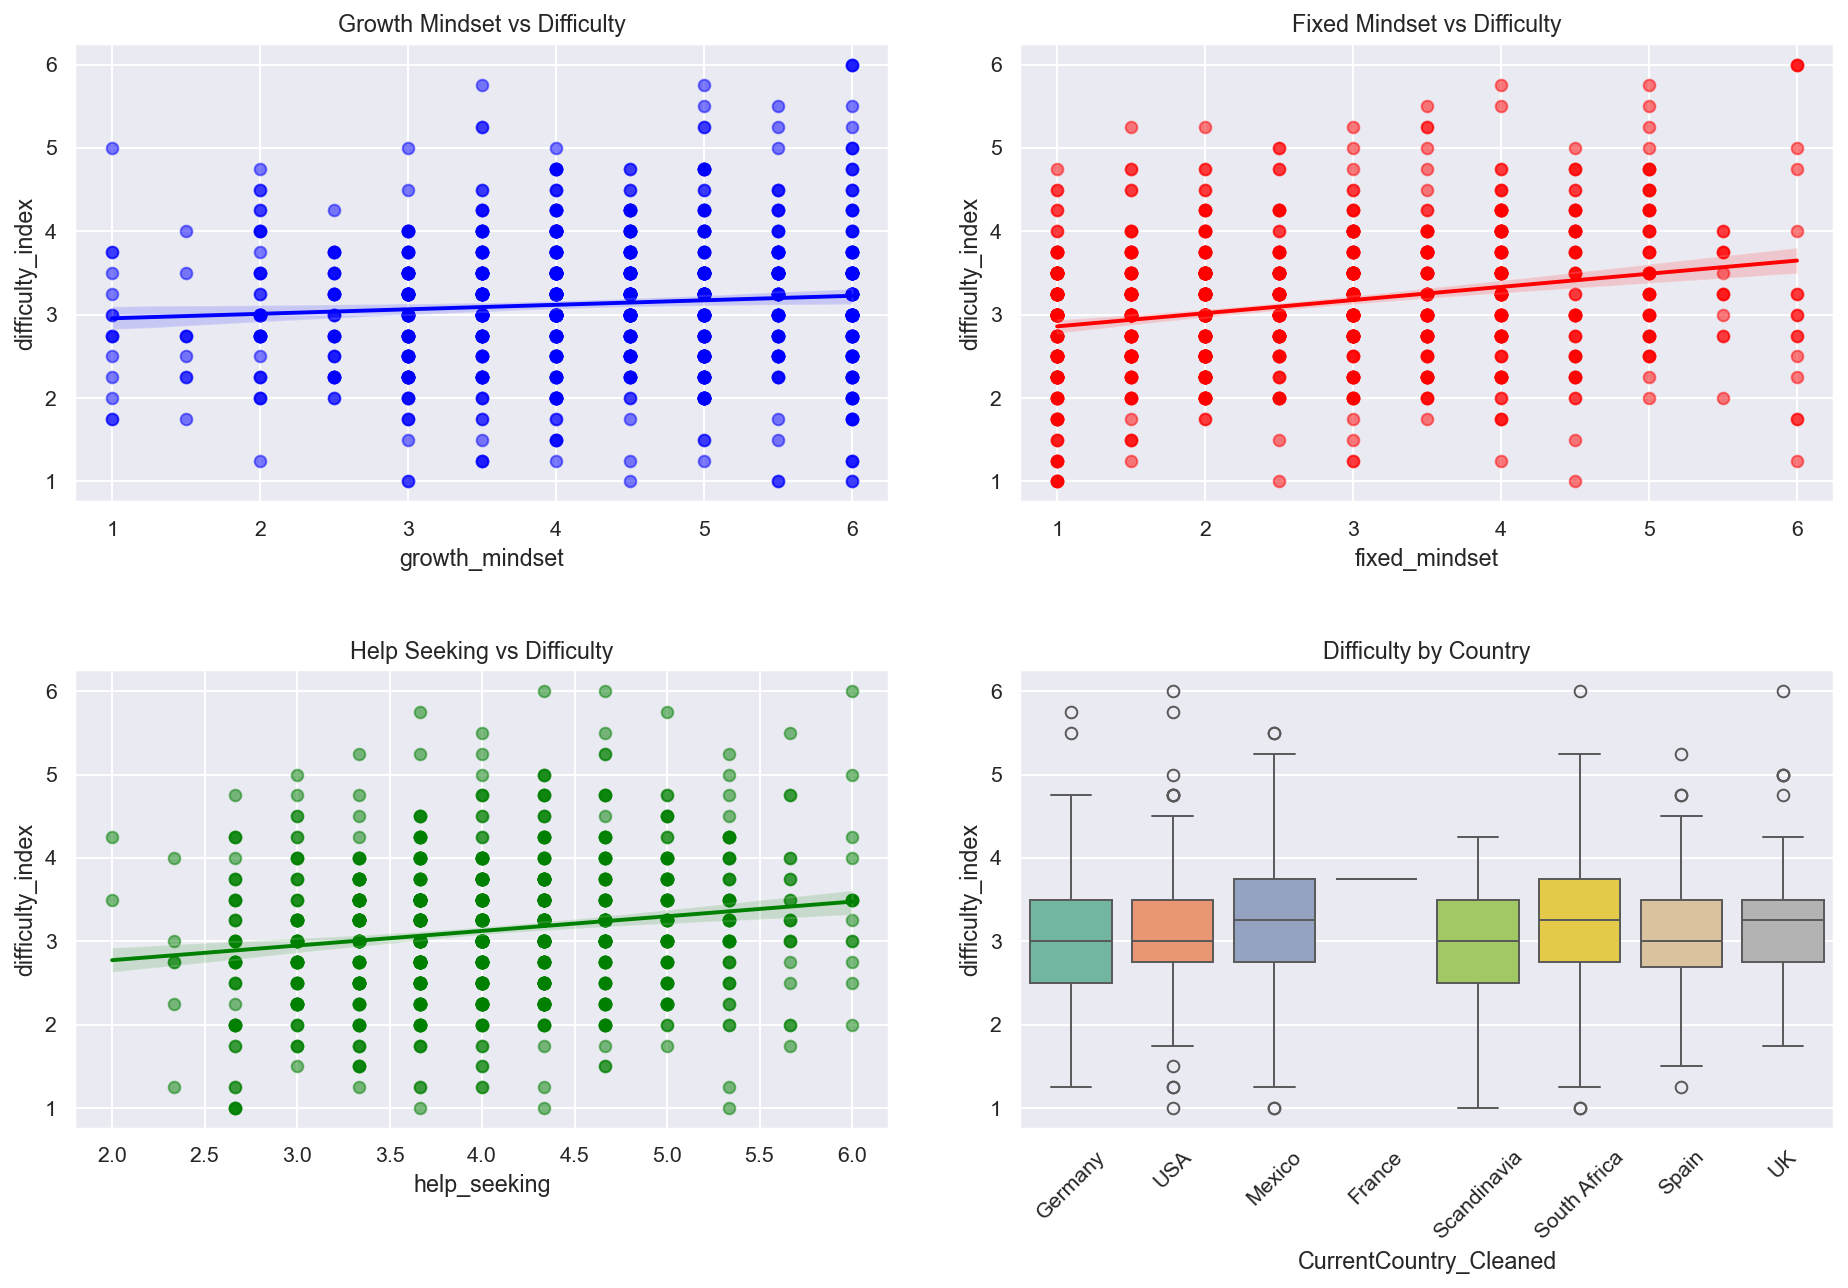

<Figure size 896x672 with 0 Axes>

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
})

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

sns.set_theme()


fig, axes = plt.subplots(2, 2, figsize=(14, 10))


sns.regplot(
    data=df,
    x="growth_mindset",
    y="difficulty_index",
    ax=axes[0, 0],
    scatter_kws={"alpha":0.5},
    line_kws={"linewidth":2},
    color="blue"
)
axes[0, 0].set_title("Growth Mindset vs Difficulty")


sns.regplot(
    data=df,
    x="fixed_mindset",
    y="difficulty_index",
    ax=axes[0, 1],
    scatter_kws={"alpha":0.5},
    line_kws={"linewidth":2},
    color="red"
)
axes[0, 1].set_title("Fixed Mindset vs Difficulty")


sns.regplot(
    data=df,
    x="help_seeking",
    y="difficulty_index",
    ax=axes[1, 0],
    scatter_kws={"alpha":0.5},
    line_kws={"linewidth":2},
    color="green"
)
axes[1, 0].set_title("Help Seeking vs Difficulty")


sns.boxplot(
    data=df,
    x="CurrentCountry_Cleaned",
    y="difficulty_index",
    ax=axes[1, 1],
    palette="Set2"
)
axes[1, 1].set_title("Difficulty by Country")
axes[1, 1].tick_params(axis='x', rotation=45)



plt.tight_layout(pad=3.0)

plt.savefig("final_figure.png", dpi=300, bbox_inches='tight')
plt.show()
plt.tight_layout()
plt.show()

Gonna clean it up for presentation


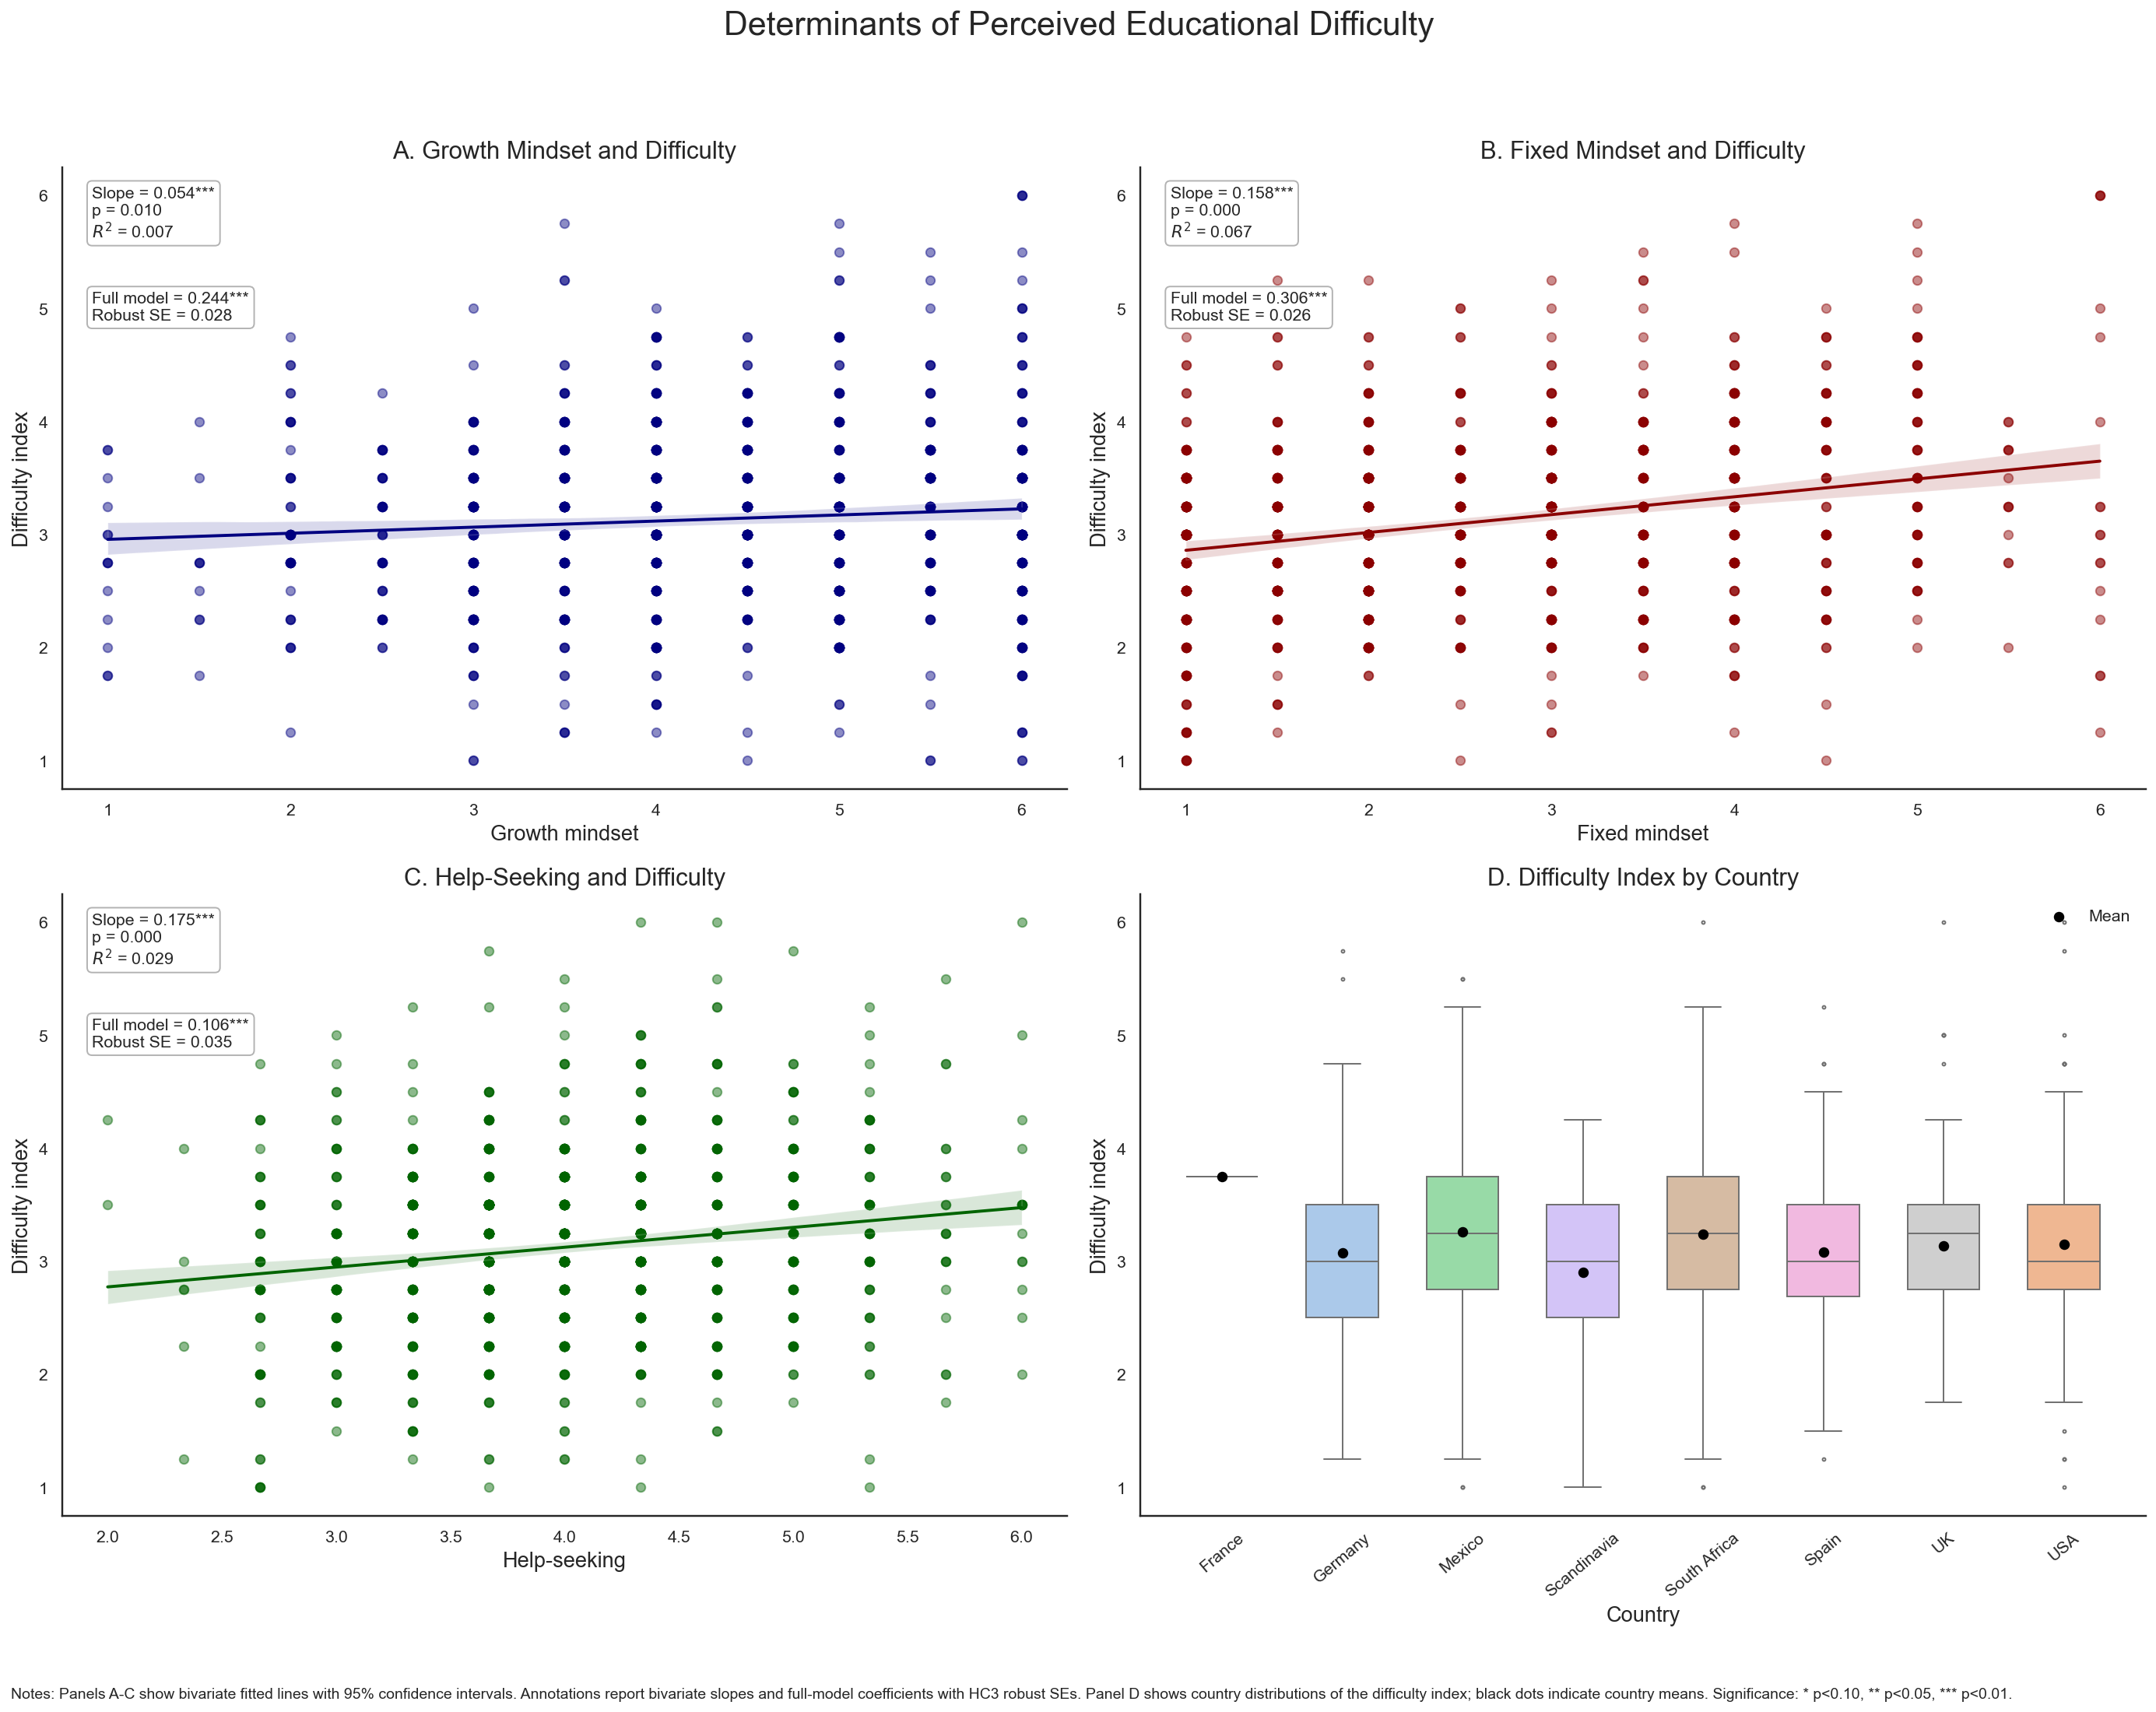

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

plt.close('all')  

sns.set_style("white")
plt.rcParams.update({
    "figure.dpi": 140,
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def add_bivariate_annotation(ax, data, xvar, yvar):
    temp = data[[xvar, yvar]].dropna().copy()
    Xb = sm.add_constant(temp[xvar])
    mb = sm.OLS(temp[yvar], Xb).fit()

    slope = mb.params[xvar]
    pval = mb.pvalues[xvar]
    r2 = mb.rsquared

    if pval < 0.01:
        stars = "***"
    elif pval < 0.05:
        stars = "**"
    elif pval < 0.10:
        stars = "*"
    else:
        stars = ""

    text = f"Slope = {slope:.3f}{stars}\np = {pval:.3f}\n$R^2$ = {r2:.3f}"
    ax.text(
        0.03, 0.97, text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.7")
    )

def add_full_model_annotation(ax, varname, model):
    if varname not in model.params.index:
        return

    coef = model.params[varname]
    se = model.bse[varname]
    pval = model.pvalues[varname]

    if pval < 0.01:
        stars = "***"
    elif pval < 0.05:
        stars = "**"
    elif pval < 0.10:
        stars = "*"
    else:
        stars = ""

    text = f"Full model = {coef:.3f}{stars}\nRobust SE = {se:.3f}"
    ax.text(
        0.03, 0.80, text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.7")
    )

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

fig.suptitle("Determinants of Perceived Educational Difficulty", fontsize=22, y=0.98)


sns.regplot(
    data=df,
    x="growth_mindset",
    y="difficulty_index",
    ax=axes[0, 0],
    ci=95,
    scatter_kws={"alpha": 0.45, "s": 35},
    line_kws={"linewidth": 2},
    color="navy"
)
axes[0, 0].set_title("A. Growth Mindset and Difficulty")
axes[0, 0].set_xlabel("Growth mindset")
axes[0, 0].set_ylabel("Difficulty index")
add_bivariate_annotation(axes[0, 0], df, "growth_mindset", "difficulty_index")
add_full_model_annotation(axes[0, 0], "growth_mindset", model)


sns.regplot(
    data=df,
    x="fixed_mindset",
    y="difficulty_index",
    ax=axes[0, 1],
    ci=95,
    scatter_kws={"alpha": 0.45, "s": 35},
    line_kws={"linewidth": 2},
    color="darkred"
)
axes[0, 1].set_title("B. Fixed Mindset and Difficulty")
axes[0, 1].set_xlabel("Fixed mindset")
axes[0, 1].set_ylabel("Difficulty index")
add_bivariate_annotation(axes[0, 1], df, "fixed_mindset", "difficulty_index")
add_full_model_annotation(axes[0, 1], "fixed_mindset", model)


sns.regplot(
    data=df,
    x="help_seeking",
    y="difficulty_index",
    ax=axes[1, 0],
    ci=95,
    scatter_kws={"alpha": 0.45, "s": 35},
    line_kws={"linewidth": 2},
    color="darkgreen"
)
axes[1, 0].set_title("C. Help-Seeking and Difficulty")
axes[1, 0].set_xlabel("Help-seeking")
axes[1, 0].set_ylabel("Difficulty index")
add_bivariate_annotation(axes[1, 0], df, "help_seeking", "difficulty_index")
add_full_model_annotation(axes[1, 0], "help_seeking", model)


country_order = sorted(df["CurrentCountry_Cleaned"].dropna().unique())

sns.boxplot(
    data=df,
    x="CurrentCountry_Cleaned",
    y="difficulty_index",
    ax=axes[1, 1],
    order=country_order,
    width=0.6,
    fliersize=2,
    linewidth=1,
    hue="CurrentCountry_Cleaned",
    dodge=False,
    legend=False,
    palette="pastel"
)
axes[1, 1].set_title("D. Difficulty Index by Country")
axes[1, 1].set_xlabel("Country")
axes[1, 1].set_ylabel("Difficulty index")
axes[1, 1].tick_params(axis="x", rotation=40)

country_means = (
    df.groupby("CurrentCountry_Cleaned")["difficulty_index"]
    .mean()
    .reindex(country_order)
)

axes[1, 1].scatter(
    np.arange(len(country_order)),
    country_means.values,
    color="black",
    s=35,
    zorder=5,
    label="Mean"
)
axes[1, 1].legend(frameon=False, loc="upper right")

fig.text(
    0.01, 0.01,
    "Notes: Panels A-C show bivariate fitted lines with 95% confidence intervals. "
    "Annotations report bivariate slopes and full-model coefficients with HC3 robust SEs. "
    "Panel D shows country distributions of the difficulty index; black dots indicate country means. "
    "Significance: * p<0.10, ** p<0.05, *** p<0.01.",
    ha="left", va="bottom", fontsize=10
)

plt.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.show()



**Conclusion**

The results show that mindset and behavior are important predictors of perceived difficulty. Both growth mindset and fixed mindset are positively related to difficulty, with fixed mindset having a stronger effect. Help-seeking is also associated with higher perceived difficulty, likely because students who struggle more are more likely to seek help. In contrast, country differences are not significant once these factors are controlled for. Overall, individual characteristics matter more than country in explaining perceived difficulty.
